## Imports

In [1]:
%matplotlib widget
%load_ext autoreload
%autoreload 2
import sys
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1" 
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=4"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
sys.path.append(os.path.abspath(".."))
from fields import RandomField
from simulations import Simulator
import matplotlib.pyplot as plt 
import jax.numpy as jnp

In [2]:
f2 = RandomField(size=jnp.array([8., 8.]), seed=5, delta_k=0.2*jnp.pi, interpolate=False, verbose=False)
f2_grid = RandomField(size=jnp.array([8., 8.]), seed=5, delta_k=0.2*jnp.pi, interpolate=False, verbose=False, tesselation_args={"discretization_points": "grid", "points_per_cell": 1})

## Data Generation

In [2]:
sim_2d_large = Simulator.from_file("data/sim_2d_large")

loaded Simulator from data/sim_2d_large with parameters: Field type: RandomField, 
D: 1, n_particles: 2^21, seed: 42, name: Simulator_a0a5c6d37fc649ab 
dt: 0.002, t_end: 33, delta_t_save: 0.002, 

opened existing zarr store
They have been overwritten with the current Simulator parameters.


In [6]:
sim_2d_large = Simulator(f2, n_particles=2**21, n_timesteps=2**14, storage_dir="data/sim_2d_large", verbose=False)
sim_2d_large.run(save_continuous=False, save_discretized=False, recompute=False, save_transitions=True, verbose=True)

They have been overwritten with the current Simulator parameters.
data already exists, not resimulated


<Group file://data/sim_2d_large/root.zarr>

## Cell residence times

In [ ]:
sim_2d_large.plot_cell_residence_times(25)

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(7, 3), width_ratios=[3, 4], constrained_layout=True)
sim_2d_large.plot_cell_residence_times(25, ax_cell=ax[0], ax_all=ax[1], metric_init="rate", toggle_graph=False, t_max_init=0.1)
for i, ax in enumerate(ax):
    ax.set_title(f"({chr(97 + i)})", loc="left", fontweight="bold", x=0.05, y=1, pad= -15)
plt.savefig("figures/sim_2d_large_residence_times.png", dpi=300)

## Subgraph Inference

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(7, 3), width_ratios=[3, 4], constrained_layout=True)
sim_2d_large.plot_cell_residence_times(25, ax_cell=ax[0], ax_all=ax[1], metric_init="rate", toggle_graph=True, t_max_init=0.1, in_selection_init="22", toggle_model=True)
plt.savefig("figures/sim_2d_large_residence_times_conditional.png", dpi=300)

## Graph Inference

Initial loss: 3.10e-02
Final loss: 5.43e-03 after {'max_steps': 512, 'num_steps': Array(512, dtype=int32, weak_type=True)} iterations with status optimistix._solution.RESULTS<The maximum number of steps was reached in the nonlinear solver. The problem may not be solveable (e.g., a root-find on a function that has no roots), or you may need to increase `max_steps`.>


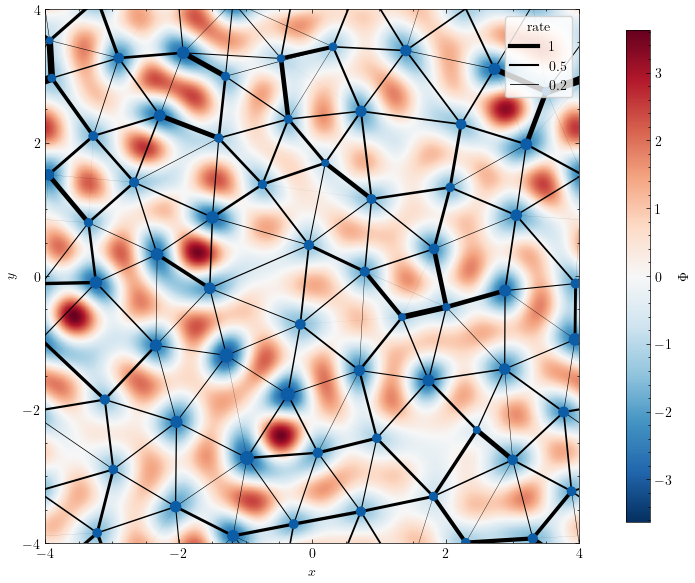

In [ ]:
_ = sim_2d_large.fit_graph_model(recompute=True, verbose=True, threshold=0.08)
# plt.savefig("figures/sim_2d_large_graph.pdf")


(<Figure size 1400x1600 with 12 Axes>,
 (<Axes: title={'center': 'Fitted Laplacian'}>,
  <Axes: >,
  <Axes: title={'center': 'Data propagator at t=8.320'}>,
  <Axes: title={'center': 'Model propagator at t=8.320'}>,
  <Axes: title={'center': 'Data - model'}>,
  <Axes: title={'center': 'Data standard deviation'}>),
 <matplotlib.widgets.Slider at 0x7304f4478080>)

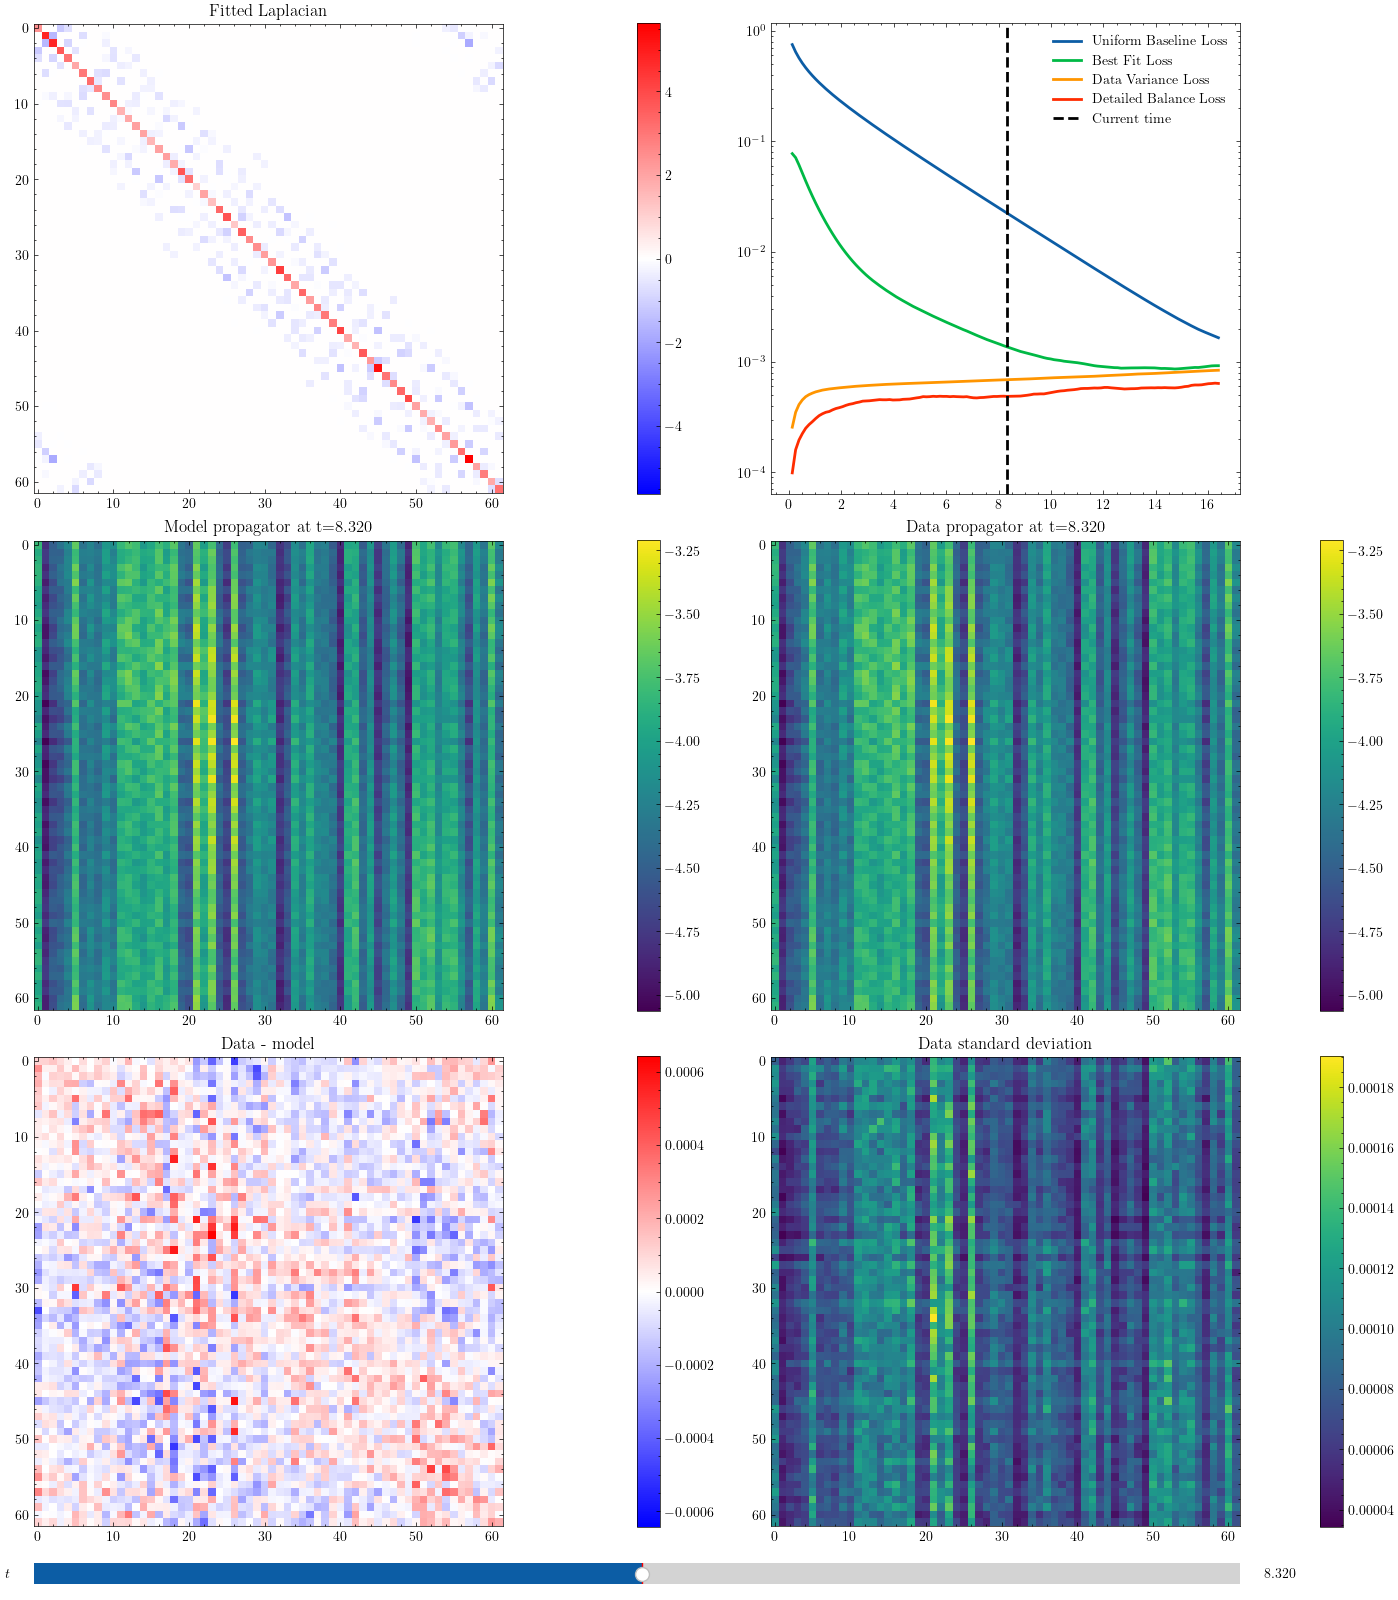

In [3]:
sim_2d_large.show_fit_diagnostics()

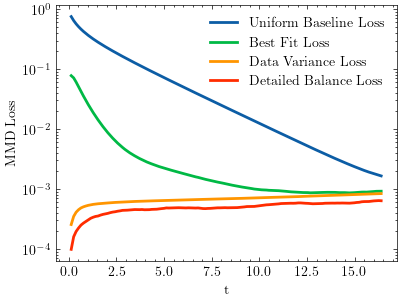

In [15]:
fig, ax = plt.subplots(figsize=(4, 3),  constrained_layout=True)
sim_2d_large.show_fit_diagnostics(ax_metrics=ax, j_init=False)
plt.savefig("figures/sim_2d_large_fit_diagnostics.eps")

## Propagator

Loading propagator data...
Using stored propagator at t=0.
Prepared 129 propagator snapshots.
Computed color normalization ranges.
Interactive slider and checkbox initialized.
Propagator plot ready.


(<Figure size 1000x1000 with 4 Axes>,
 <Axes: xlabel='$x$', ylabel='$y$'>,
 <matplotlib.widgets.CheckButtons at 0x78fa58232900>)

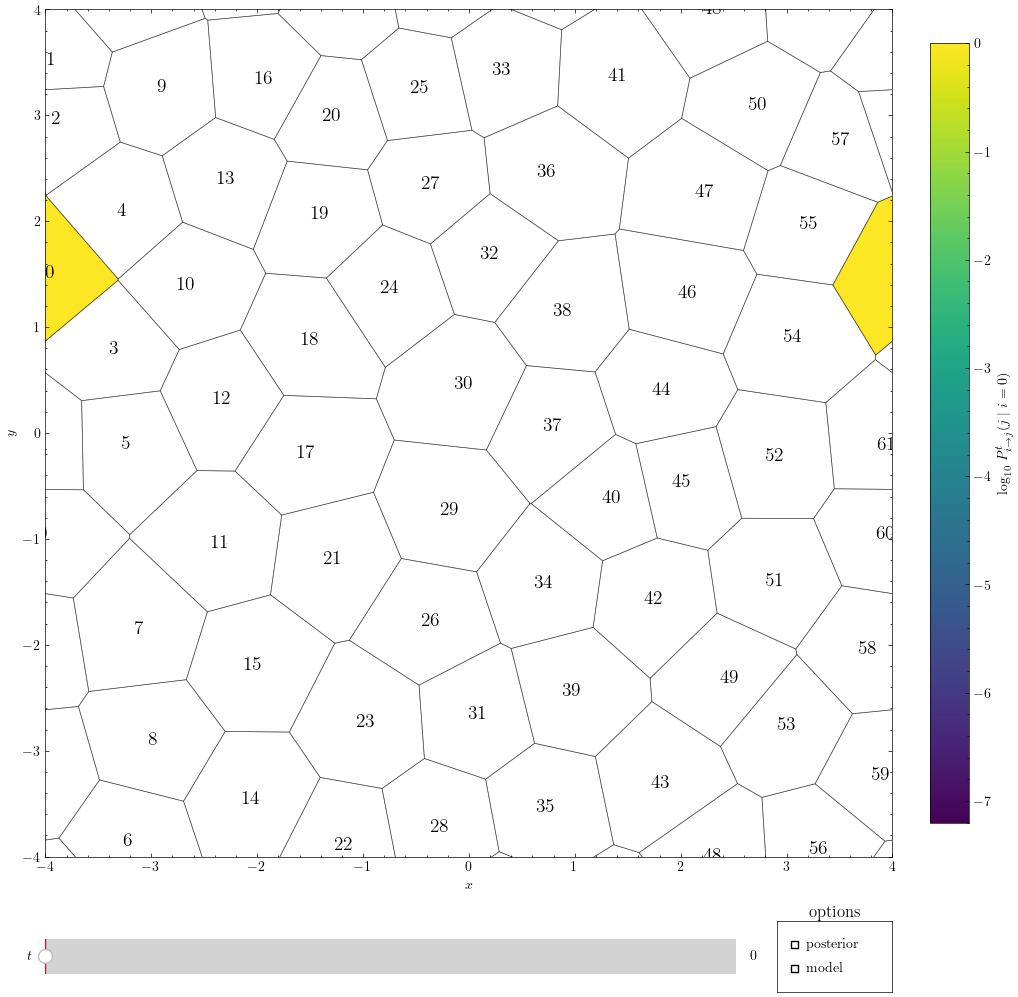

In [7]:
sim_2d_large.plot_propagator()

In [ ]:
from helpers.plotting_simulation import display_cell_scalar_field
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import numpy as np

vert0_id = 29
target_times = np.array([0.1, 1.0, 5.0], dtype=float)

prop_arr = sim_2d_large.zarr_root["propagator"]
prop = np.asarray(prop_arr[:, :, :, 0], dtype=float)

delta_t_steps = float(prop_arr.attrs["delta_t"])
delta_t = delta_t_steps * float(sim_2d_large.dt)
times_data = np.arange(prop.shape[0], dtype=float) * delta_t

# Match plot_propagator behavior: prepend delta-initial condition if t=0 slice is missing/invalid.
row_sums0 = np.sum(np.clip(prop[0], 0.0, np.inf), axis=-1)
has_t0_data = bool(np.any(np.isfinite(row_sums0) & (row_sums0 > 1e-12)))
if not has_t0_data:
    identity = np.eye(prop.shape[1], dtype=float)
    prop = np.concatenate([identity[None, :, :], np.clip(prop, 0.0, np.inf)], axis=0)
    times_data = np.arange(prop.shape[0], dtype=float) * delta_t
else:
    prop = np.clip(prop, 0.0, np.inf)

time_ids = [int(np.argmin(np.abs(times_data - t))) for t in target_times]
values_list = [prop[jj, vert0_id, :] for jj in time_ids]

# Shared log scale across all three panels.
all_vals = np.concatenate(values_list)
pos = all_vals[all_vals > 0]
vmin = np.log10(float(np.min(pos))) if pos.size > 0 else -12.0
vmax = np.log10(float(np.max(pos))) if pos.size > 0 else 0.0
if vmin == vmax:
    vmax = vmin + 1e-6
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.get_cmap("viridis")

fig, axs = plt.subplots(1, 3, figsize=(7, 2.3), constrained_layout=True)

for i, (ax, vals, jj) in enumerate(zip(axs, values_list, time_ids)):
    setattr(ax, "_diffsim_field", sim_2d_large.field)
    poly = display_cell_scalar_field(ax, vals, show_cell_ids=False, cmap="viridis")

    base_cell_ids = np.asarray(getattr(poly, "_diffsim_base_cell_ids"), dtype=int)
    plot_vals = np.asarray(vals, dtype=float)[base_cell_ids]
    with np.errstate(divide="ignore", invalid="ignore"):
        mapped = np.log10(plot_vals)
    finite = np.isfinite(mapped)
    mapped_safe = np.where(finite, mapped, norm.vmin)
    facecolors = np.asarray(cmap(norm(mapped_safe)))
    facecolors[~finite, 3] = 0.0
    poly.set_facecolors(facecolors)

    half = np.asarray(sim_2d_large.field.size, dtype=float) / 2
    ax.set_xlim(-half[0], half[0])
    ax.set_ylim(-half[1], half[1])
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(f"({chr(97 + i)}) t = {times_data[jj]:.1f}", loc="left", fontweight="bold", x=0.05, y=1, pad=-15, bbox={'facecolor': 'white', 'alpha': 0.8, 'pad': 2})
    ax.set_xlabel(r"$x$")
    if i == 0:
        ax.set_ylabel(r"$y$")
    else:
        ax.set_ylabel("")
        ax.tick_params(axis="y", which="both", left=False, labelleft=False)

sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axs, fraction=0.03, pad=0.02)
cbar.set_label(rf"$\log_{{10}} P(i\mid t, i_0 = {vert0_id})$")
# plt.savefig("figures/sim_2d_propagator_panels.pdf")

In [ ]:
from helpers.plotting_simulation import display_cell_scalar_field
from helpers.fullgraph_inference import propagator_from_laplacian, dehermitianize
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import numpy as np

vert0_id = 29
t_target = 0.5

prop_arr = sim_2d_large.zarr_root["propagator"]
prop = np.asarray(prop_arr[:, :, :, 0], dtype=float)

# Build positive-time axis exactly as in diagnostics/propagator helpers.
delta_t_steps = float(prop_arr.attrs["delta_t"])
delta_t = delta_t_steps * float(sim_2d_large.dt)
times_all = np.arange(prop.shape[0], dtype=float) * delta_t
pos_mask = times_all > 0
prop_pos = prop[pos_mask]
times_pos = times_all[pos_mask]

jj = int(np.argmin(np.abs(times_pos - t_target)))
t_sel = float(times_pos[jj])

# Data propagator slice for selected in-cell.
data_vals = np.clip(prop_pos[jj, vert0_id, :], 0.0, np.inf)

# Model propagator slice at the same time.
laplacian = np.asarray(sim_2d_large.zarr_root["edge_weights"], dtype=np.float32)
stationary = np.asarray(sim_2d_large.zarr_root["stationary"][:, 0], dtype=np.float32)
model_prop = np.asarray(
    dehermitianize(
        propagator_from_laplacian(laplacian, np.float32(t_sel)),
        stationary,
    ),
    dtype=float,
 )
model_vals = np.clip(model_prop[vert0_id, :], 0.0, np.inf)

# Shared log normalization across data/model.
all_vals = np.concatenate([data_vals, model_vals])
pos = all_vals[all_vals > 0]
vmin = np.log10(float(np.min(pos))) if pos.size > 0 else -12.0
vmax = np.log10(float(np.max(pos))) if pos.size > 0 else 0.0
if vmin == vmax:
    vmax = vmin + 1e-6
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.get_cmap("viridis")

fig, axs = plt.subplots(1, 2, figsize=(7, 3.3), constrained_layout=True)
labels = ["data", "model"]
values_list = [data_vals, model_vals]

for i, (ax, vals, label) in enumerate(zip(axs, values_list, labels)):
    setattr(ax, "_diffsim_field", sim_2d_large.field)
    poly = display_cell_scalar_field(ax, vals, show_cell_ids=False, cmap="viridis")

    base_cell_ids = np.asarray(getattr(poly, "_diffsim_base_cell_ids"), dtype=int)
    plot_vals = np.asarray(vals, dtype=float)[base_cell_ids]
    with np.errstate(divide="ignore", invalid="ignore"):
        mapped = np.log10(plot_vals)
    finite = np.isfinite(mapped)
    mapped_safe = np.where(finite, mapped, norm.vmin)
    facecolors = np.asarray(cmap(norm(mapped_safe)))
    facecolors[~finite, 3] = 0.0
    poly.set_facecolors(facecolors)

    half = np.asarray(sim_2d_large.field.size, dtype=float) / 2
    ax.set_xlim(-half[0], half[0])
    ax.set_ylim(-half[1], half[1])
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(
        f"({chr(97 + i)}) {label}",
        loc="left",
        fontweight="bold",
        x=0.05,
        y=1,
        pad=-15,
        bbox={"facecolor": "white", "alpha": 0.8, "pad": 2},
    )
    ax.set_xlabel(r"$x$")
    if i == 0:
        ax.set_ylabel(r"$y$")
    else:
        ax.set_ylabel("")
        ax.tick_params(axis="y", which="both", left=False, labelleft=False)

sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axs, fraction=0.03, pad=0.02)
cbar.set_label(rf"$\log_{{10}} P(i\mid t={t_sel:.1f}, i_0 = {vert0_id})$")
plt.savefig("figures/sim_2d_propagator_model_comparison.pdf")

## Comparison to naive grid

In [ ]:
sim_2d_large_grid = Simulator(f2_grid, n_particles=2**21, n_timesteps=2**14, storage_dir="data/sim_2d_large_grid", verbose=False)
sim_2d_large_grid.run(save_continuous=False, save_discretized=False, recompute=False, save_transitions=False, verbose=True)

Initial loss: 3.35e-02
Final loss: 9.50e-03 after {'max_steps': 512, 'num_steps': Array(189, dtype=int32, weak_type=True)} iterations with status optimistix._solution.RESULTS<>


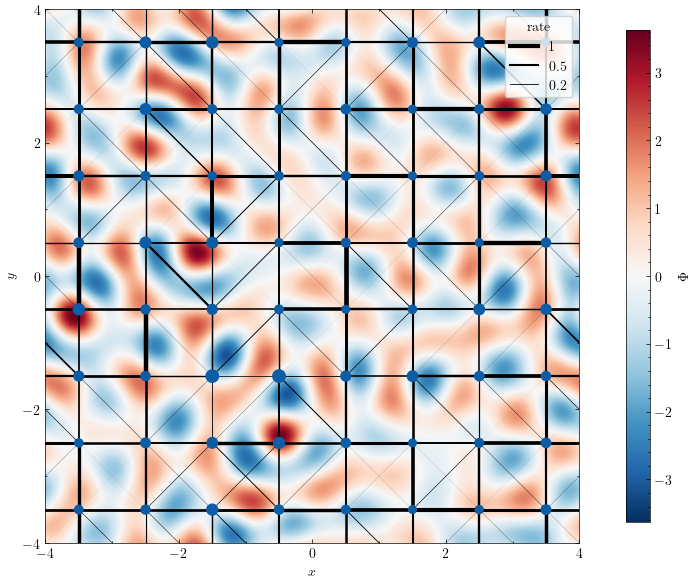

In [18]:
_ = sim_2d_large_grid.fit_graph_model(recompute=True, verbose=True, threshold=0.08)
plt.savefig("figures/sim_2d_large_grid_graph.pdf")

In [16]:
sim_2d_large_grid = Simulator.from_file("data/sim_2d_large_grid")

loaded Simulator from data/sim_2d_large_grid with parameters: Field type: RandomField, 
D: 1, n_particles: 2^21, seed: 42, name: Simulator_fd69c4cb24aa6760 
dt: 0.002, t_end: 33, delta_t_save: 0.002, 

opened existing zarr store


(<Figure size 1400x1600 with 12 Axes>,
 (<Axes: title={'center': 'Fitted Laplacian'}>,
  <Axes: xlabel='t', ylabel='MMD Loss'>,
  <Axes: title={'center': 'Data propagator at t=8.320'}>,
  <Axes: title={'center': 'Model propagator at t=8.320'}>,
  <Axes: title={'center': 'Data - model'}>,
  <Axes: title={'center': 'Data standard deviation'}>),
 <matplotlib.widgets.Slider at 0x73031857b680>)

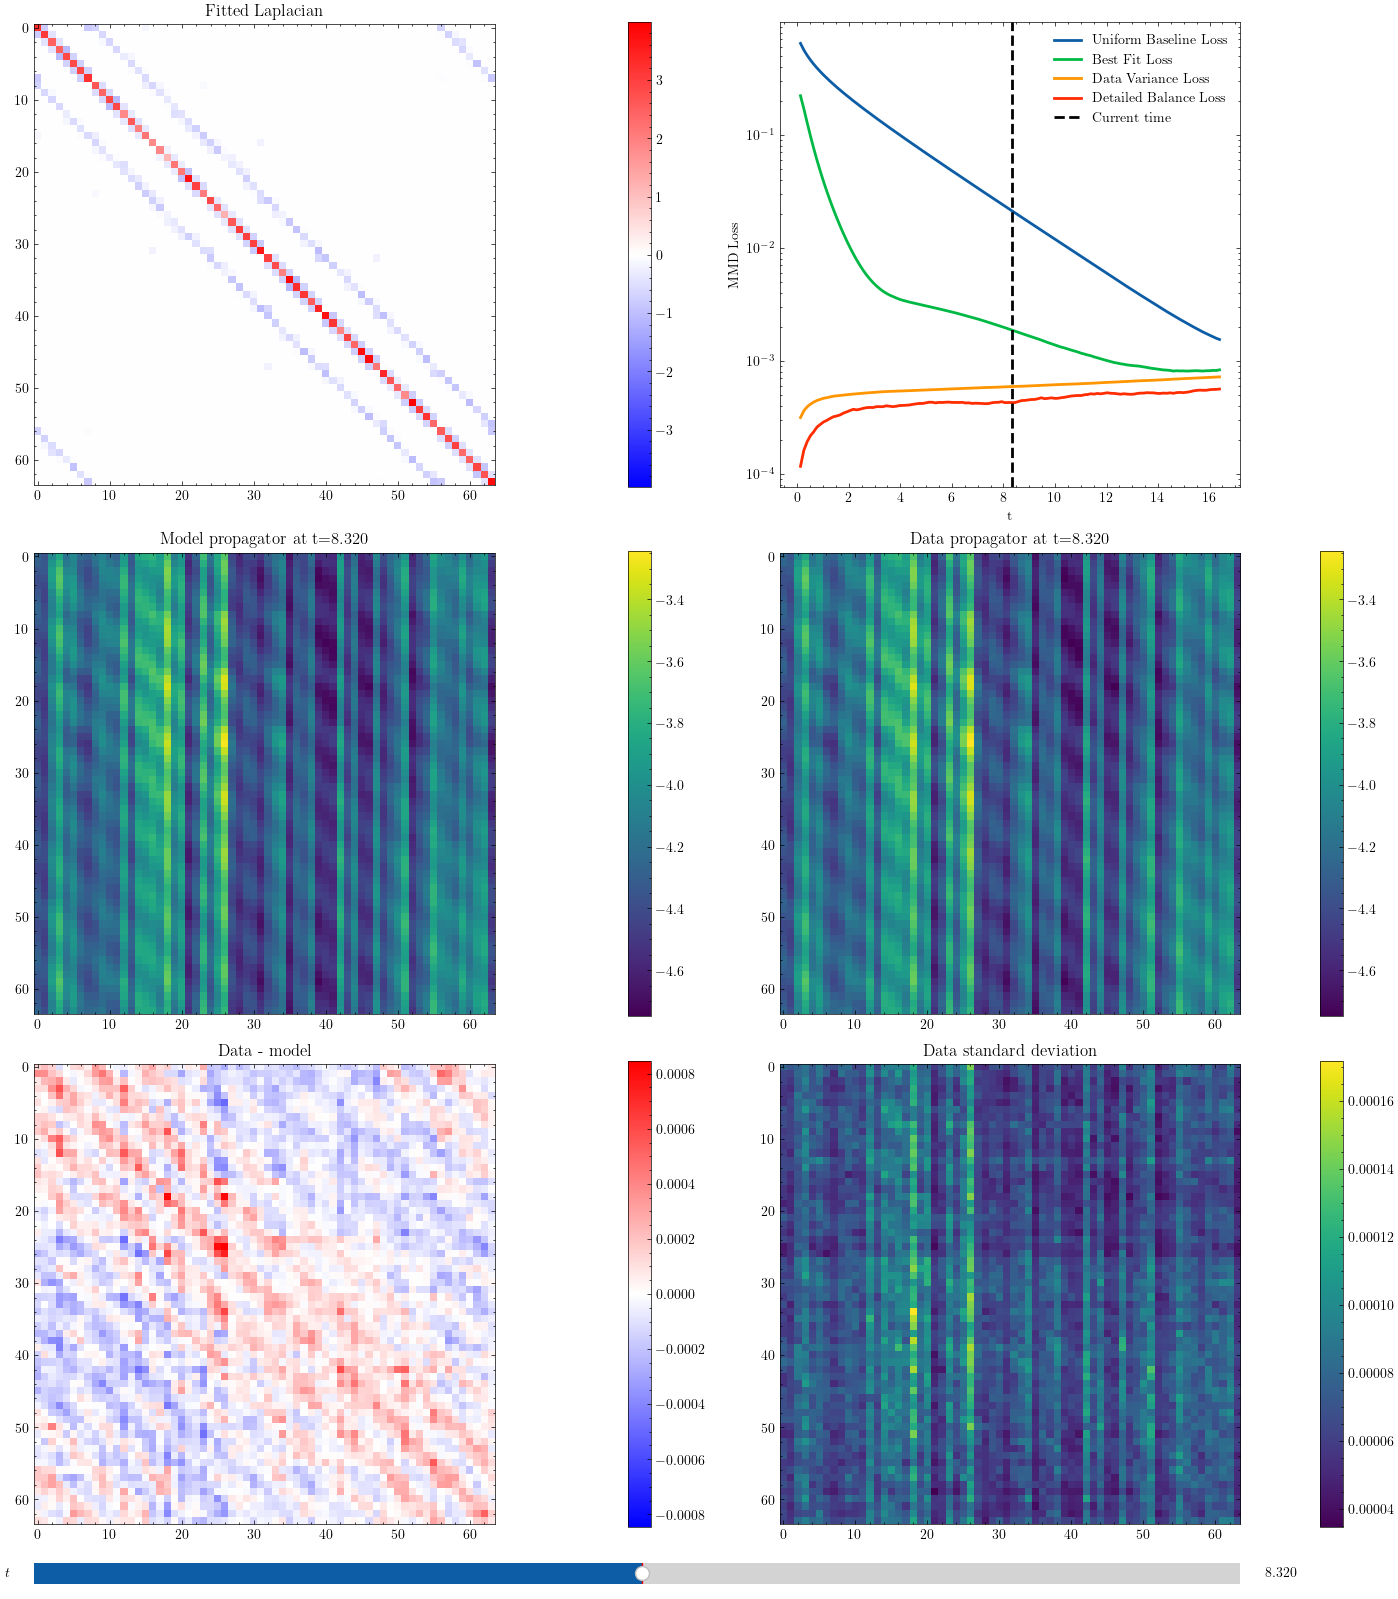

In [17]:
sim_2d_large_grid.show_fit_diagnostics()

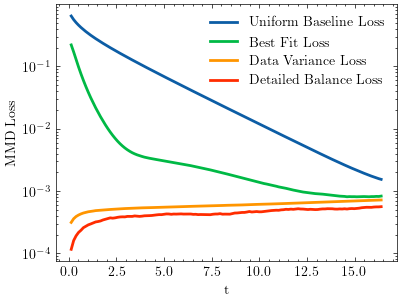

In [19]:
fig, ax = plt.subplots(figsize=(4, 3),  constrained_layout=True)
sim_2d_large_grid.show_fit_diagnostics(ax_metrics=ax, j_init=False)
plt.savefig("figures/sim_2d_large_grid_fit_diagnostics.eps")